<a href="https://colab.research.google.com/github/ronaksagar626-oss/DACS08---Hospital-Administration-Analysis/blob/main/Copy_of_Your_Ronak_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 E-Commerce Sales Analysis
## An E-Commerce Company's Path to Sustainable Growth

This notebook provides a comprehensive data analysis covering:
- 💰 **Financial Performance** — Revenue trends, best-sellers, seasonal patterns
- 👥 **Customer Insights** — Top locations, B2B vs B2C, cancellation trends
- 🚚 **Logistics & Fulfillment** — Amazon vs Merchant fulfillment comparison
- 📦 **Product Management** — High-demand categories, inventory signals
- 🔄 **Customer Satisfaction & Returns** — Return/cancellation deep-dive

---

## 📁 Step 0 — Upload Dataset

Run the cell below to upload your `sales_dataset.csv` file from your local machine.

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/sales_dataset.csv', low_memory=False)

Mounted at /content/drive


## 📦 Step 1 — Install & Import Libraries

In [ ]:
# Install any missing packages
!pip install -q seaborn plotly

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 🔍 Step 2 — Data Exploration

In [ ]:
# Load dataset
# df = pd.read_csv('sales_dataset.csv', low_memory=False) # Removed as df is now loaded from Google Drive

# Rename columns for convenience
df.columns = df.columns.str.strip()
df.rename(columns={
    'Sales Channel ': 'Sales Channel',
    'Unnamed: 22': 'extra'
}, inplace=True)

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 128,949 rows × 23 columns


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,extra
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [ ]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128949 non-null  object 
 1   Date                128949 non-null  object 
 2   Status              128949 non-null  object 
 3   Fulfilment          128949 non-null  object 
 4   Sales Channel       128949 non-null  object 
 5   ship-service-level  128949 non-null  object 
 6   Style               128949 non-null  object 
 7   SKU                 128949 non-null  object 
 8   Category            128949 non-null  object 
 9   Size                128949 non-null  object 
 10  ASIN                128949 non-null  object 
 11  Courier Status      122078 non-null  object 
 12  Qty                 128949 non-null  int64  
 13  currency            121155 non-null  object 
 14  Amount              121155 non-null  float64
 15  ship-city           128916 non-nul

In [ ]:
# Statistical summary
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order ID,128949,120352,403-4984515-8861958,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,128949,91,05-03-2022,2085,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,128949,13,Shipped,77767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fulfilment,128949,2,Amazon,89679,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sales Channel,128949,2,Amazon.in,128825,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ship-service-level,128949,2,Expedited,88596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Style,128949,1377,JNE3797,4224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SKU,128949,7195,JNE3797-KR-L,773,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,128949,9,Set,50275,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,128949,11,M,22705,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Missing value audit
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %
fulfilled-by,89679,69.55
promotion-ids,49142,38.11
extra,49041,38.03
currency,7794,6.04
Amount,7794,6.04
Courier Status,6871,5.33
ship-postal-code,33,0.03
ship-state,33,0.03
ship-city,33,0.03
ship-country,33,0.03


## 🧹 Step 3 — Data Cleaning

In [ ]:
import numpy as np
# 1. Parse Date
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y', errors='coerce')
# Drop rows where 'Date' is NaT after coercion
initial_rows = df.shape[0]
df.dropna(subset=['Date'], inplace=True)
rows_dropped = initial_rows - df.shape[0]
if rows_dropped > 0:
    print(f'Dropped {rows_dropped} rows with invalid dates.')
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Year'] = df['Date'].dt.year

# 2. Fill Amount nulls with median (as per problem statement)
median_amount = df['Amount'].median()
df['Amount'].fillna(median_amount, inplace=True)
print(f'Filled {df["Amount"].isna().sum()} Amount nulls with median: ₹{median_amount:.2f}')

# 3. Fill Courier Status nulls
df['Courier Status'].fillna('Unknown', inplace=True)

# 4. Standardise ship-state (uppercase)
df['ship-state'] = df['ship-state'].str.upper().str.strip()

# 5. Drop mostly-empty columns
df.drop(columns=['extra', 'fulfilled-by'], inplace=True, errors='ignore')

# 6. Revenue column (Qty × Amount)
df['Revenue'] = df['Qty'] * df['Amount']

print(f'\n✅ Cleaning complete. Final shape: {df.shape}')
df.head(3)

Dropped 55097 rows with invalid dates.
Filled 0 Amount nulls with median: ₹612.00

✅ Cleaning complete. Final shape: (73852, 26)


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,Month,Month_Name,Week,Year,Revenue
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,MAHARASHTRA,400081.0,IN,NaN,False,4,Apr,17,2022,0.0
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,4,Apr,17,2022,406.0
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,4,Apr,17,2022,329.0


## 💰 Step 4 — Financial Performance Analysis

In [ ]:
# ── 4.1 Total Revenue & Order Volume KPIs ──────────────────────────────────
total_revenue   = df['Revenue'].sum()
total_orders    = df['Order ID'].nunique()
avg_order_value = df.groupby('Order ID')['Revenue'].sum().mean()
total_units     = df['Qty'].sum()

print('=' * 50)
print(f'  Total Revenue     : ₹{total_revenue:,.0f}')
print(f'  Unique Orders     : {total_orders:,}')
print(f'  Avg Order Value   : ₹{avg_order_value:,.2f}')
print(f'  Total Units Sold  : {total_units:,}')
print('=' * 50)

  Total Revenue     : ₹43,535,114
  Unique Orders     : 68,916
  Avg Order Value   : ₹631.71
  Total Units Sold  : 66,595


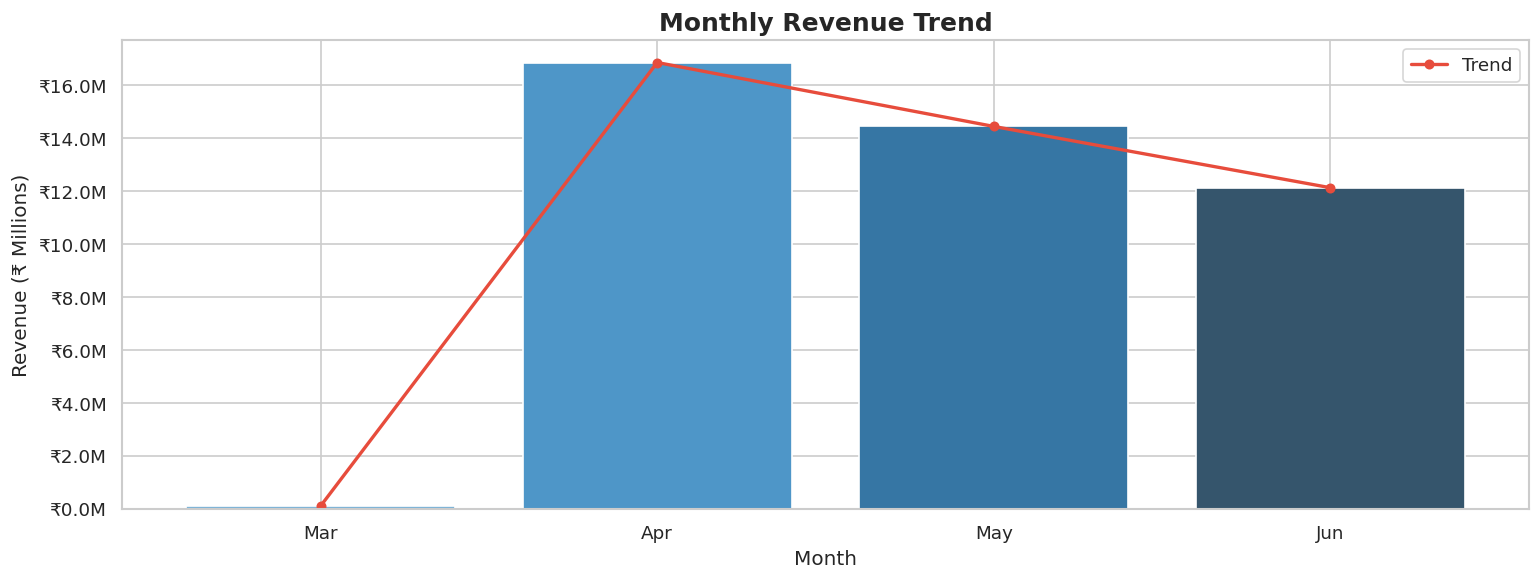

In [ ]:
# ── 4.2 Monthly Revenue Trend ──────────────────────────────────────────────
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_rev = (
    df.groupby('Month_Name')['Revenue']
    .sum()
    .reindex([m for m in month_order if m in df['Month_Name'].unique()])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(monthly_rev['Month_Name'], monthly_rev['Revenue'] / 1e6,
              color=sns.color_palette('Blues_d', len(monthly_rev)))
ax.plot(monthly_rev['Month_Name'], monthly_rev['Revenue'] / 1e6,
        'o-', color='#e74c3c', linewidth=2, markersize=5, label='Trend')
ax.set_title('Monthly Revenue Trend', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (₹ Millions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.1f}M'))
ax.legend()
plt.tight_layout()
plt.show()

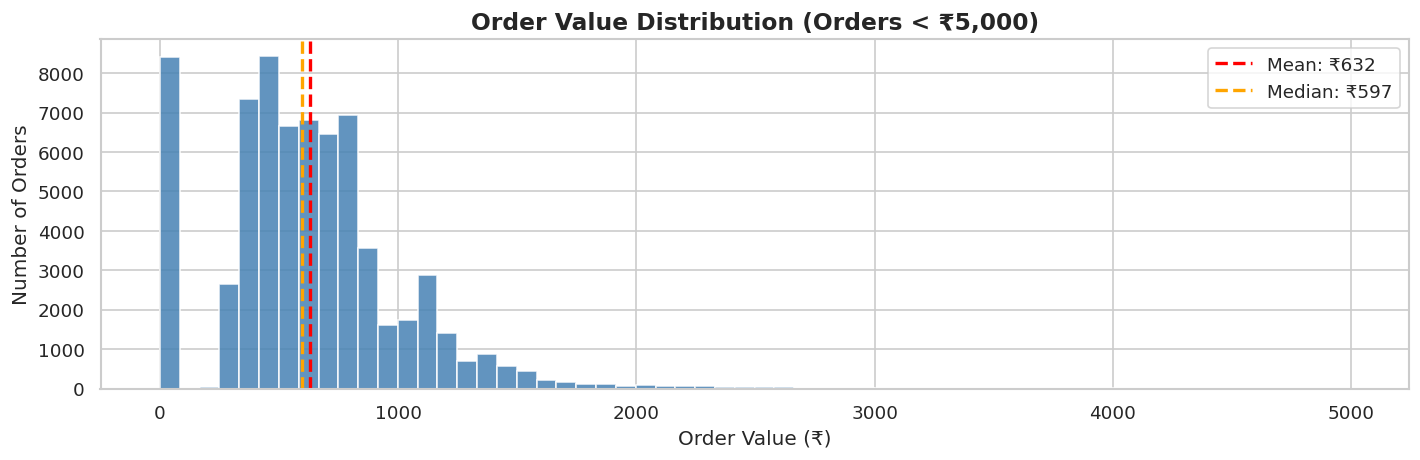

In [ ]:
# ── 4.3 Average Order Value Distribution ──────────────────────────────────
order_values = df.groupby('Order ID')['Revenue'].sum()

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(order_values[order_values < 5000], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(order_values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ₹{order_values.mean():.0f}')
ax.axvline(order_values.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: ₹{order_values.median():.0f}')
ax.set_title('Order Value Distribution (Orders < ₹5,000)', fontsize=14, fontweight='bold')
ax.set_xlabel('Order Value (₹)')
ax.set_ylabel('Number of Orders')
ax.legend()
plt.tight_layout()
plt.show()

## 👥 Step 5 — Customer Insights

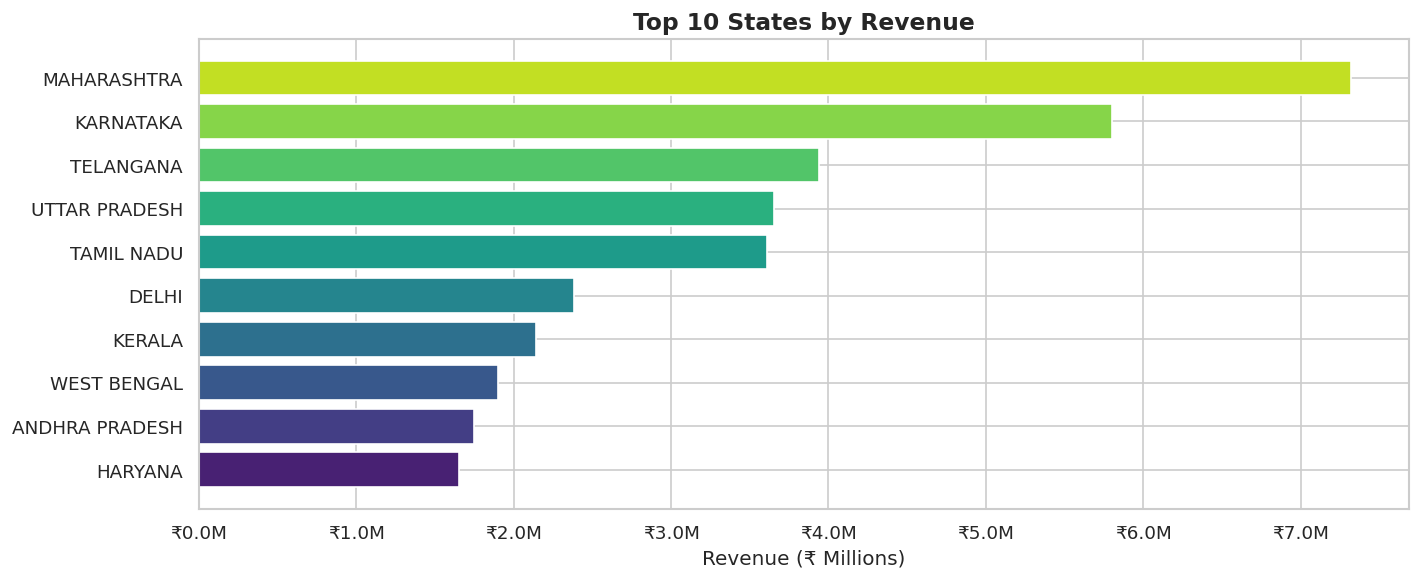

In [ ]:
# ── 5.1 Top 10 States by Revenue ──────────────────────────────────────────
state_rev = (
    df.groupby('ship-state')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(state_rev.index[::-1], state_rev.values[::-1] / 1e6,
               color=sns.color_palette('viridis', 10))
ax.set_title('Top 10 States by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (₹ Millions)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.1f}M'))
plt.tight_layout()
plt.show()

     Orders      Revenue  Avg_Amount  Revenue_Share_%
B2B                                                  
B2C   73305  43132647.05      647.18            99.08
B2B     547    402467.00      706.19             0.92


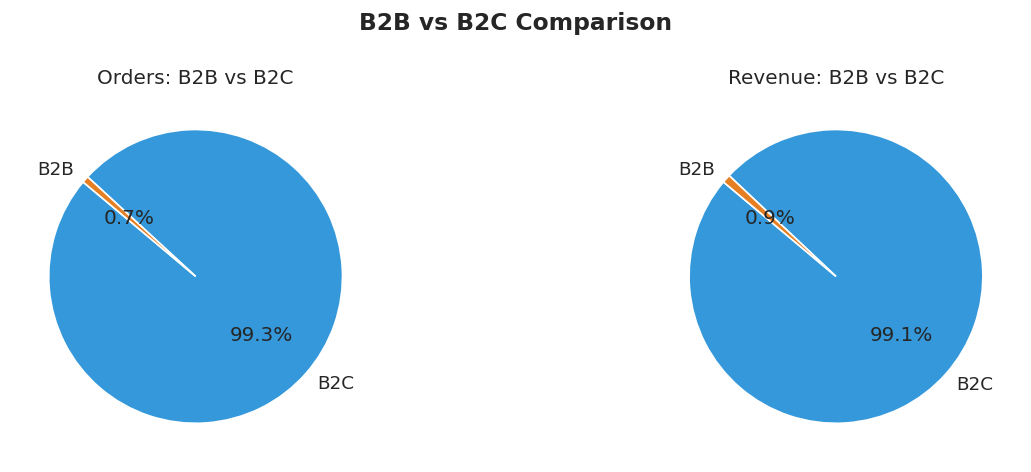

In [ ]:
# ── 5.2 B2B vs B2C Analysis ────────────────────────────────────────────────
b2b_summary = df.groupby('B2B').agg(
    Orders=('Order ID', 'count'),
    Revenue=('Revenue', 'sum'),
    Avg_Amount=('Amount', 'mean')
).rename(index={True: 'B2B', False: 'B2C'})
b2b_summary['Revenue_Share_%'] = (b2b_summary['Revenue'] / b2b_summary['Revenue'].sum() * 100).round(2)
print(b2b_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['B2C', 'B2B']
colors = ['#3498db', '#e67e22']

axes[0].pie(b2b_summary['Orders'], labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[0].set_title('Orders: B2B vs B2C')

axes[1].pie(b2b_summary['Revenue'], labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[1].set_title('Revenue: B2B vs B2C')

plt.suptitle('B2B vs B2C Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

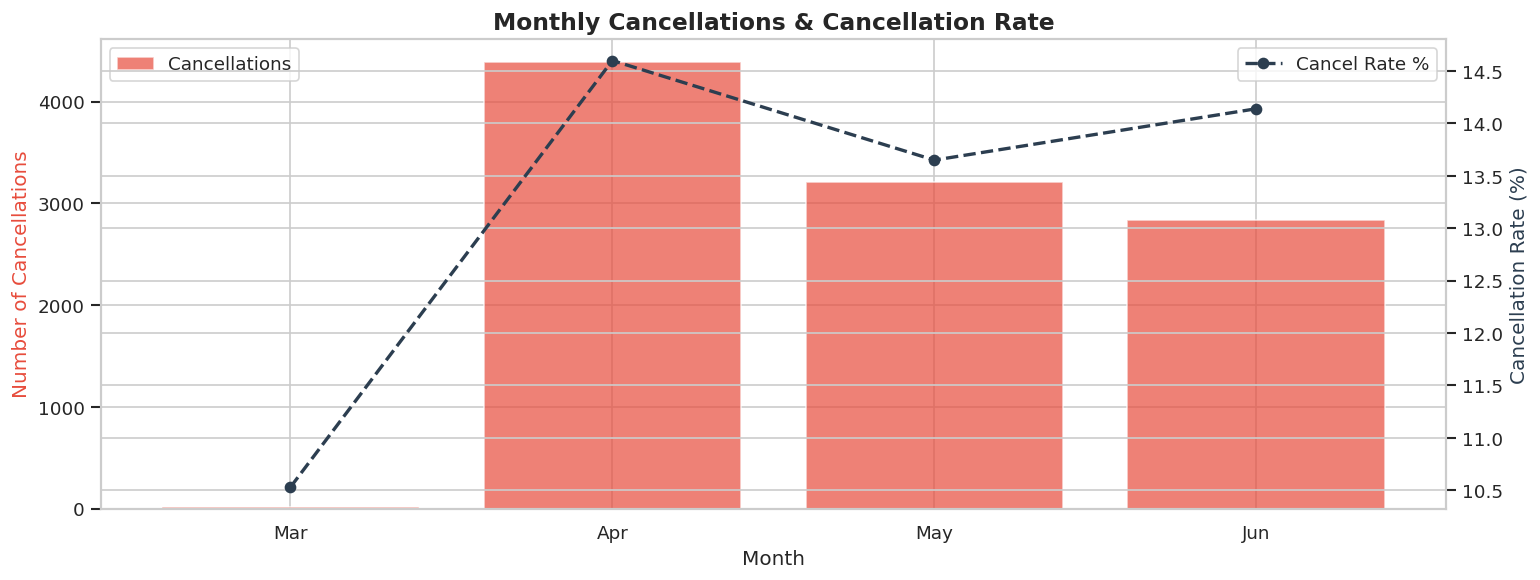

In [ ]:
# ── 5.3 Order Cancellation Trend by Month ─────────────────────────────────
cancelled = df[df['Status'] == 'Cancelled']
cancel_monthly = (
    cancelled.groupby('Month_Name').size()
    .reindex([m for m in month_order if m in df['Month_Name'].unique()])
    .reset_index(name='Cancellations')
)
total_monthly = (
    df.groupby('Month_Name').size()
    .reindex([m for m in month_order if m in df['Month_Name'].unique()])
    .reset_index(name='Total')
)
cancel_rate = cancel_monthly.merge(total_monthly, on='Month_Name')
cancel_rate['Cancel_%'] = (cancel_rate['Cancellations'] / cancel_rate['Total'] * 100).round(2)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()
ax1.bar(cancel_rate['Month_Name'], cancel_rate['Cancellations'], color='#e74c3c', alpha=0.7, label='Cancellations')
ax2.plot(cancel_rate['Month_Name'], cancel_rate['Cancel_%'], 'o--', color='#2c3e50', linewidth=2, label='Cancel Rate %')
ax1.set_title('Monthly Cancellations & Cancellation Rate', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Cancellations', color='#e74c3c')
ax2.set_ylabel('Cancellation Rate (%)', color='#2c3e50')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 🚚 Step 6 — Logistics & Fulfillment

            Orders      Revenue  Cancel_Rate
Fulfilment                                  
Amazon       49478  30422851.00        12.58
Merchant     24374  13112263.05        17.38


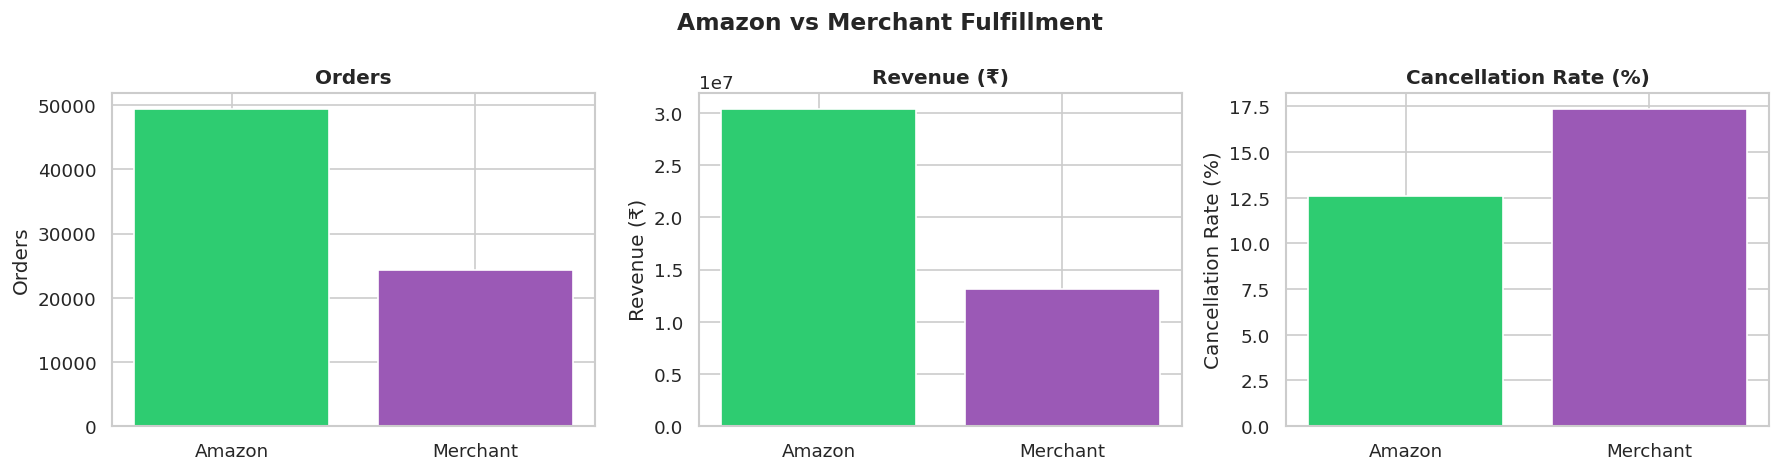

In [ ]:
# ── 6.1 Amazon vs Merchant Fulfillment ────────────────────────────────────
fulfil = df.groupby('Fulfilment').agg(
    Orders=('Order ID', 'count'),
    Revenue=('Revenue', 'sum'),
    Cancel_Rate=('Status', lambda x: (x == 'Cancelled').mean() * 100)
).round(2)
print(fulfil)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [('Orders', 'Orders'), ('Revenue', 'Revenue (₹)'), ('Cancel_Rate', 'Cancellation Rate (%)')]
colors_f = ['#2ecc71', '#9b59b6']

for ax, (col, label) in zip(axes, metrics):
    ax.bar(fulfil.index, fulfil[col], color=colors_f)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(label)

plt.suptitle('Amazon vs Merchant Fulfillment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

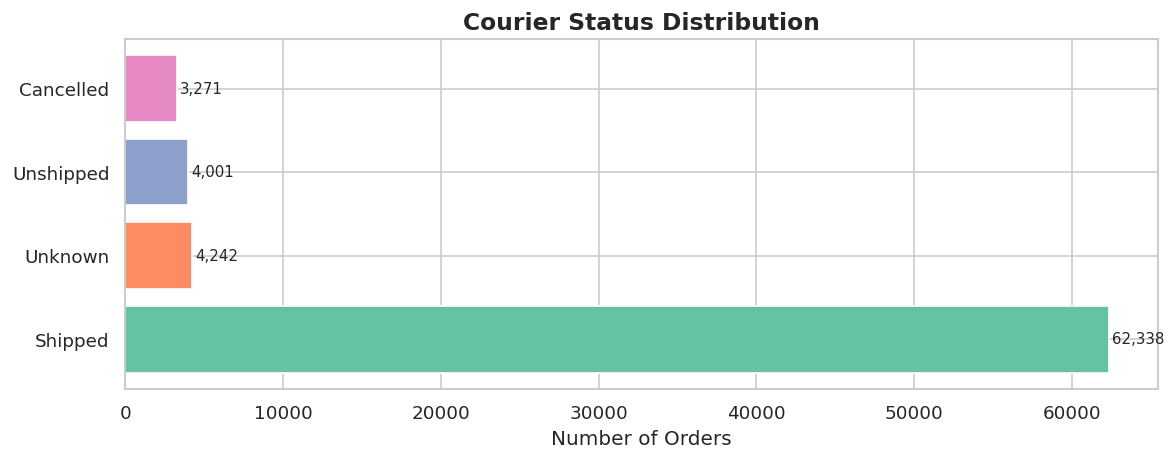

In [ ]:
# ── 6.2 Courier Status Breakdown ──────────────────────────────────────────
courier_counts = df['Courier Status'].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(courier_counts.index, courier_counts.values, color=sns.color_palette('Set2', len(courier_counts)))
ax.set_title('Courier Status Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Orders')
for i, v in enumerate(courier_counts.values):
    ax.text(v + 200, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

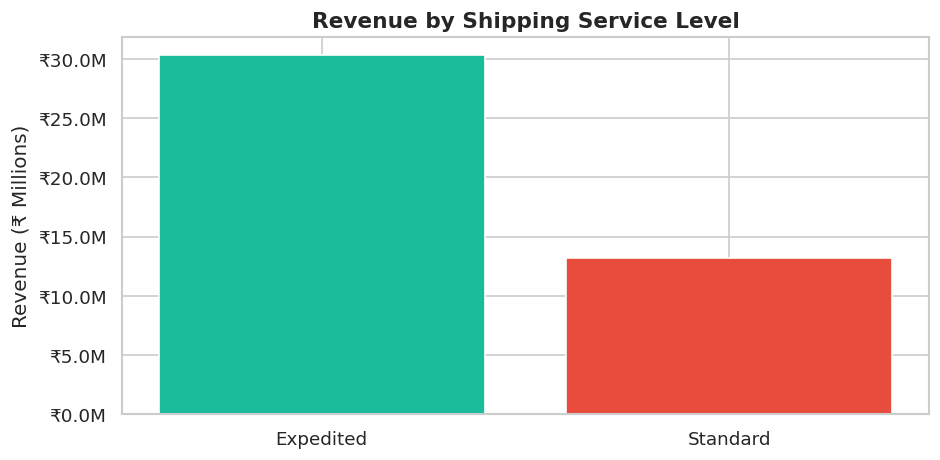

In [ ]:
# ── 6.3 Shipping Service Level ────────────────────────────────────────────
service_rev = df.groupby('ship-service-level')['Revenue'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(service_rev.index, service_rev.values / 1e6, color=['#1abc9c', '#e74c3c'])
ax.set_title('Revenue by Shipping Service Level', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (₹ Millions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.1f}M'))
plt.tight_layout()
plt.show()

## 📦 Step 7 — Product Management & Inventory

                   Revenue  Units_Sold  Avg_Order_Value
Category                                               
Set            21437735.00       25548           820.83
kurta          11690826.05       25299           468.17
Western Dress   6445220.00        8418           752.68
Top             3074779.00        5826           527.79
Ethnic Dress     440864.00         599           728.05
Blouse           271801.00         534           510.94
Bottom           103548.00         280           379.98
Saree             69426.00          88           772.28
Dupatta             915.00           3           305.00


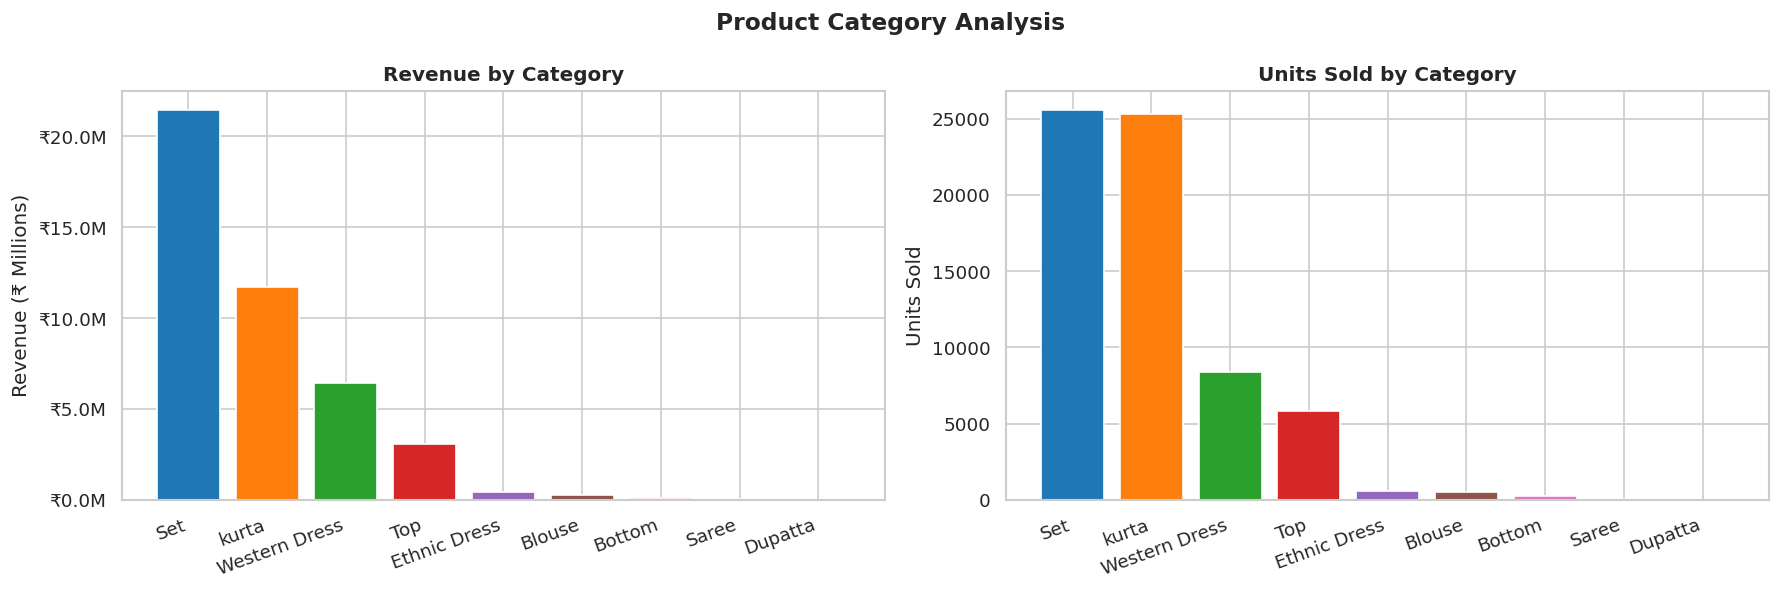

In [ ]:
# ── 7.1 Revenue & Units by Category ───────────────────────────────────────
cat = df.groupby('Category').agg(
    Revenue=('Revenue', 'sum'),
    Units_Sold=('Qty', 'sum'),
    Avg_Order_Value=('Amount', 'mean')
).sort_values('Revenue', ascending=False)
print(cat.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors_cat = sns.color_palette('tab10', len(cat))

# Revenue
axes[0].bar(cat.index, cat['Revenue'] / 1e6, color=colors_cat)
axes[0].set_title('Revenue by Category', fontweight='bold')
axes[0].set_ylabel('Revenue (₹ Millions)')
axes[0].set_xticklabels(cat.index, rotation=20, ha='right')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.1f}M'))

# Units sold
axes[1].bar(cat.index, cat['Units_Sold'], color=colors_cat)
axes[1].set_title('Units Sold by Category', fontweight='bold')
axes[1].set_ylabel('Units Sold')
axes[1].set_xticklabels(cat.index, rotation=20, ha='right')

plt.suptitle('Product Category Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

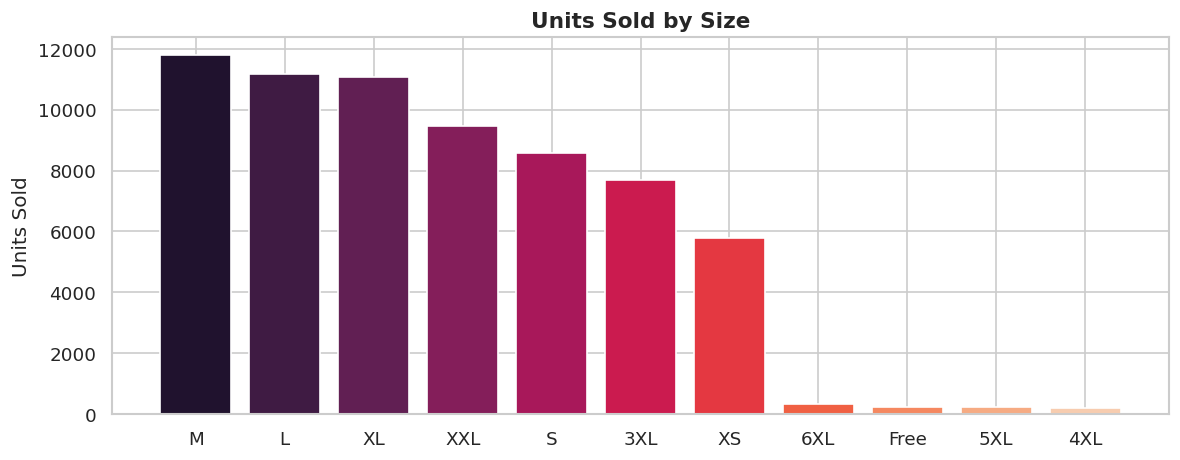

In [ ]:
# ── 7.2 Sales by Size ─────────────────────────────────────────────────────
size_order = ['XS', 'S', 'M', 'L', 'XL', 'XXL', '3XL', 'Free']
size_sales = df.groupby('Size')['Qty'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(size_sales.index, size_sales.values, color=sns.color_palette('rocket', len(size_sales)))
ax.set_title('Units Sold by Size', fontsize=13, fontweight='bold')
ax.set_ylabel('Units Sold')
plt.tight_layout()
plt.show()

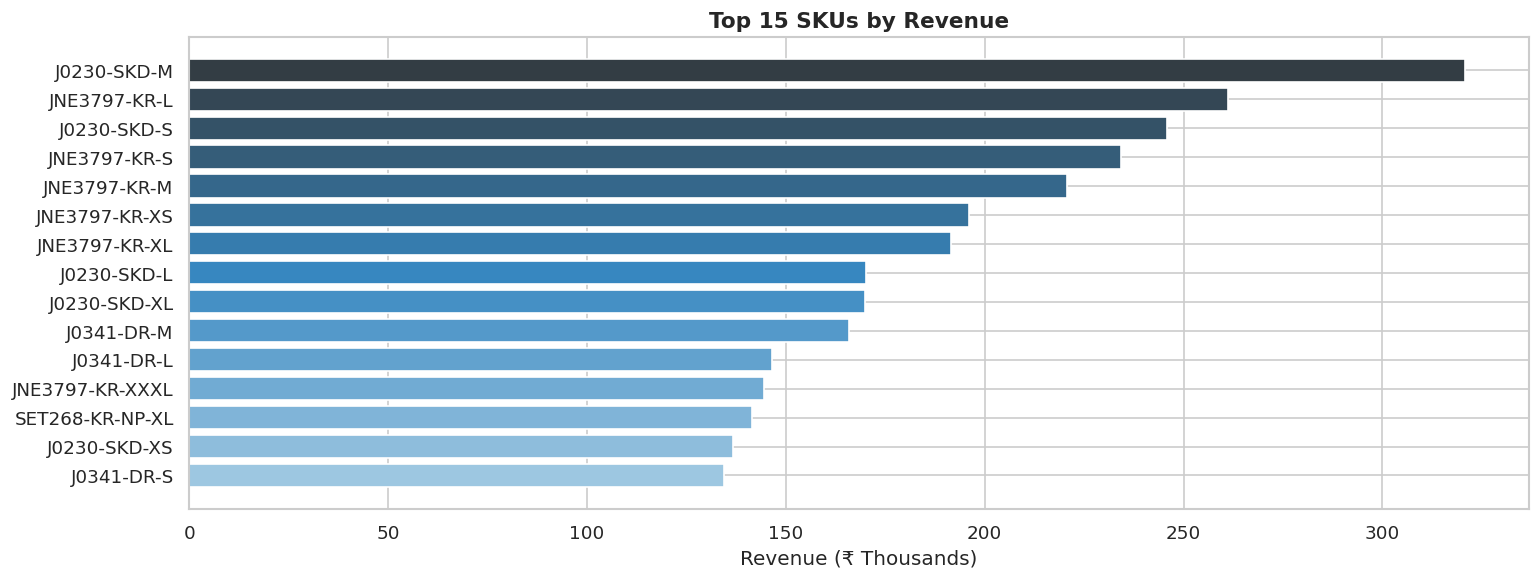

In [ ]:
# ── 7.3 Top 15 SKUs by Revenue ────────────────────────────────────────────
sku_rev = df.groupby('SKU')['Revenue'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13, 5))
ax.barh(sku_rev.index[::-1], sku_rev.values[::-1] / 1e3,
        color=sns.color_palette('Blues_d', 15))
ax.set_title('Top 15 SKUs by Revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (₹ Thousands)')
plt.tight_layout()
plt.show()

## 🔄 Step 8 — Customer Satisfaction & Returns

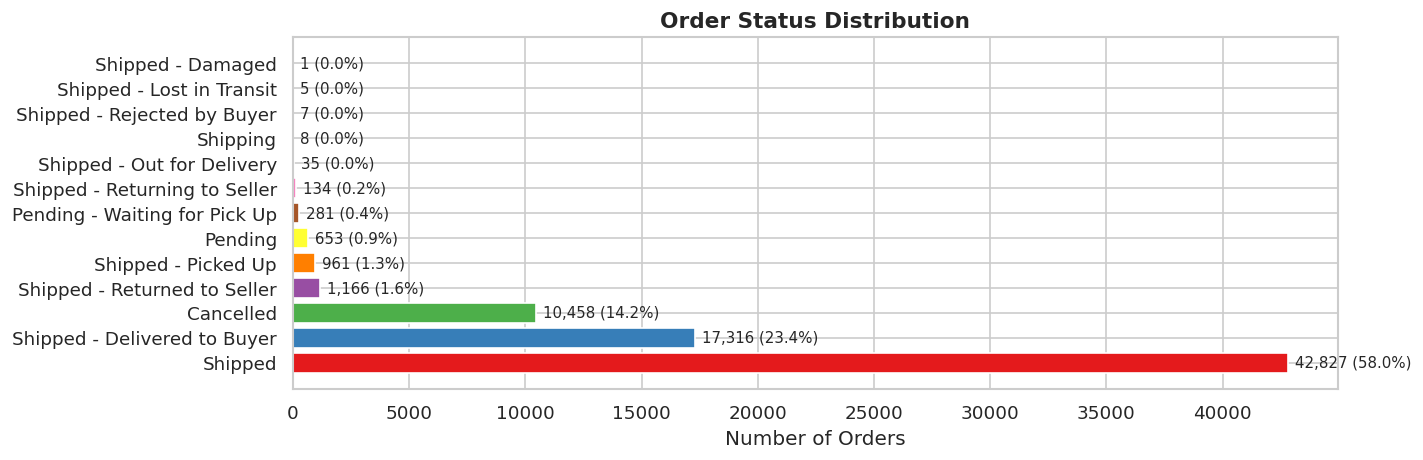

In [ ]:
# ── 8.1 Order Status Distribution ─────────────────────────────────────────
status_counts = df['Status'].value_counts()

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.barh(status_counts.index, status_counts.values,
               color=sns.color_palette('Set1', len(status_counts)))
ax.set_title('Order Status Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Orders')
for i, v in enumerate(status_counts.values):
    ax.text(v + 300, i, f'{v:,} ({v/len(df)*100:.1f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.show()

               Total  Negative  Negative_Rate_%
Category                                       
kurta          28177      4587            16.28
Western Dress   9370      1517            16.19
Set            28406      4598            16.19
Bottom           316        51            16.14
Blouse           572        77            13.46
Saree             97        13            13.40
Ethnic Dress     655        87            13.28
Top             6256       828            13.24
Dupatta            3         0             0.00


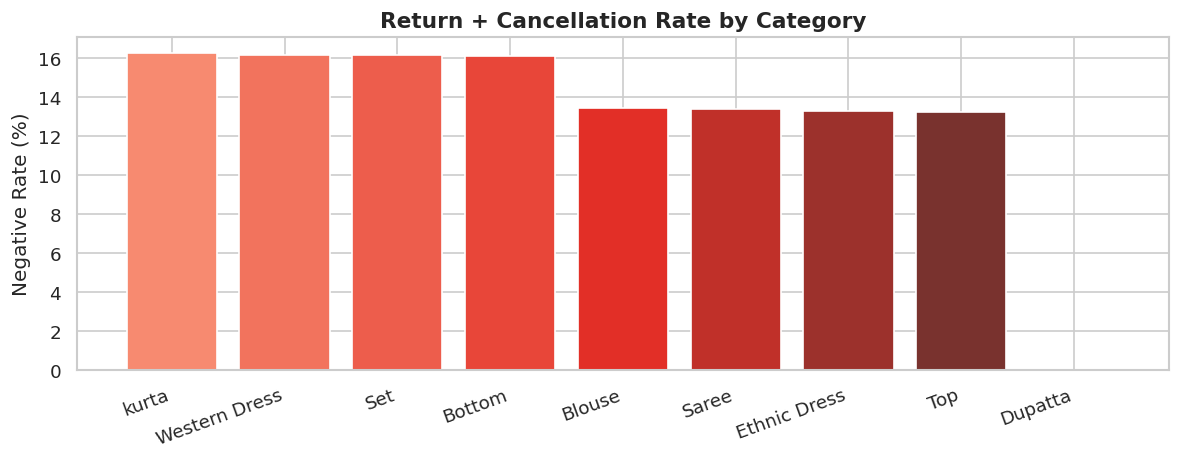

In [ ]:
# ── 8.2 Returns & Cancellations by Category ────────────────────────────────
negative_statuses = ['Cancelled', 'Shipped - Returned to Seller', 'Shipped - Returning to Seller']
df['is_negative'] = df['Status'].isin(negative_statuses)

cat_neg = df.groupby('Category').agg(
    Total=('Order ID', 'count'),
    Negative=('is_negative', 'sum')
)
cat_neg['Negative_Rate_%'] = (cat_neg['Negative'] / cat_neg['Total'] * 100).round(2)
cat_neg = cat_neg.sort_values('Negative_Rate_%', ascending=False)
print(cat_neg)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cat_neg.index, cat_neg['Negative_Rate_%'], color=sns.color_palette('Reds_d', len(cat_neg)))
ax.set_title('Return + Cancellation Rate by Category', fontsize=13, fontweight='bold')
ax.set_ylabel('Negative Rate (%)')
ax.set_xticklabels(cat_neg.index, rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# ── 8.3 Promotion Impact on Order Volume ──────────────────────────────────
df['has_promo'] = df['promotion-ids'].notna()
promo_summary = df.groupby('has_promo').agg(
    Orders=('Order ID', 'count'),
    Revenue=('Revenue', 'sum'),
    Avg_Amount=('Amount', 'mean'),
    Cancel_Rate=('Status', lambda x: (x == 'Cancelled').mean() * 100)
).rename(index={True: 'With Promo', False: 'No Promo'}).round(2)
print(promo_summary)

            Orders      Revenue  Avg_Amount  Cancel_Rate
has_promo                                               
No Promo     27430  12173738.05      605.44        37.53
With Promo   46422  31361376.00      672.53         0.35


## 📊 Step 9 — Correlation Heatmap

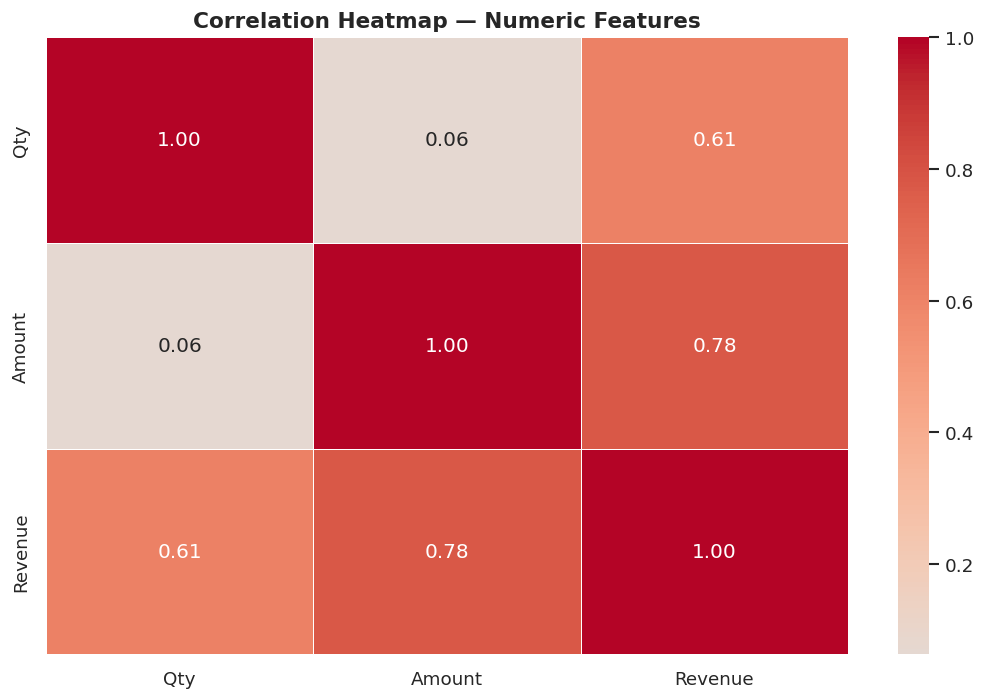

In [ ]:
numeric_cols = df.select_dtypes(include='number').drop(columns=['Month', 'Week', 'Year', 'ship-postal-code'], errors='ignore')

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🗺️ Step 10 — Interactive Geo Visualisation (Plotly)

In [ ]:
# Revenue by State — Interactive Chart
state_rev_full = df.groupby('ship-state')['Revenue'].sum().reset_index()
state_rev_full.columns = ['State', 'Revenue']

fig = px.bar(
    state_rev_full.sort_values('Revenue', ascending=False).head(20),
    x='State', y='Revenue',
    title='Top 20 States by Revenue (Interactive)',
    labels={'Revenue': 'Revenue (₹)'},
    color='Revenue',
    color_continuous_scale='Blues'
)
fig.update_layout(xaxis_tickangle=-35)
fig.show()

In [ ]:
# Interactive Category vs Size heatmap
cat_size = df.groupby(['Category', 'Size'])['Qty'].sum().reset_index()
cat_size_pivot = cat_size.pivot(index='Category', columns='Size', values='Qty').fillna(0)

fig = px.imshow(
    cat_size_pivot,
    title='Units Sold — Category × Size Heatmap',
    color_continuous_scale='YlOrRd',
    aspect='auto'
)
fig.show()

In [ ]:
df.to_csv('cleaned_sales_data.csv', index=False) # Ensure preceding cells creating 'df' have been run.
print('✅ Cleaned sales data saved to cleaned_sales_data.csv')

✅ Cleaned sales data saved to cleaned_sales_data.csv


## 🧠 Step 11 — MCQ: Test Your Understanding

Based on the analysis above, answer the following questions (solutions provided in the next cell).

**Q1.** Which state contributes the **highest revenue**?  
- a) Karnataka  
- b) Tamil Nadu  
- c) Maharashtra  
- d) Uttar Pradesh  

**Q2.** What is the **dominant product category** by units sold?  
- a) Western Dress  
- b) kurta  
- c) Set  
- d) Top  

**Q3.** Which fulfillment method handles **more orders**?  
- a) Merchant  
- b) Amazon  
- c) Both are equal  
- d) Third-party logistics  

**Q4.** What value was used to fill missing **Amount** values?  
- a) Mean  
- b) Zero  
- c) Median  
- d) Mode  

**Q5.** What share of orders are **B2B**?  
- a) ~50%  
- b) ~25%  
- c) < 1%  
- d) ~10%  

In [ ]:
# ── MCQ Answers (run to reveal) ────────────────────────────────────────────
answers = {
    'Q1': ('c', 'Maharashtra — highest cumulative revenue in the dataset.'),
    'Q2': ('c', 'Set — marginally ahead of kurta in units sold.'),
    'Q3': ('b', 'Amazon — handles ~70% of all orders.'),
    'Q4': ('c', 'Median — as specified in the problem statement to avoid outlier bias.'),
    'Q5': ('c', 'Less than 1% (<1%) of orders are B2B.'),
}
for q, (ans, explanation) in answers.items():
    print(f'{q}: ({ans}) {explanation}')

Q1: (c) Maharashtra — highest cumulative revenue in the dataset.
Q2: (c) Set — marginally ahead of kurta in units sold.
Q3: (b) Amazon — handles ~70% of all orders.
Q4: (c) Median — as specified in the problem statement to avoid outlier bias.
Q5: (c) Less than 1% (<1%) of orders are B2B.


## ✅ Step 12 — Recommendations & Conclusion

### Key Findings

| Area | Finding |
|------|-----------------------------|
| Revenue | Peaks in April–May; drop-off in later months signals seasonal demand |
| Top State | Maharashtra drives the highest revenue, followed by Karnataka |
| Best Category | Set & Kurta dominate sales — critical inventory priorities |
| Fulfillment | Amazon handles ~70% of orders with a **lower cancellation rate** than Merchant |
| Customer Type | B2B is only ~0.7% of orders but potentially higher-value per order |
| Returns | Cancellation rate varies by category — some categories need quality review |

### Recommendations

1. **Boost Merchant Fulfillment Quality** — Merchant-fulfilled orders show a higher cancellation rate; provide seller training and SLA enforcement to close the gap with Amazon fulfillment.

2. **Capitalise on Peak Months** — Run targeted promotions in March–April when demand is highest. Build inventory buffers in high-demand categories (Set, Kurta) at least 4–6 weeks in advance.

3. **Reduce Cancellations** — Identify SKUs and categories with the highest cancellation rates. Investigate whether the issue is product mismatch, payment failure, or price sensitivity.

4. **Expand in Top States** — Maharashtra, Karnataka, and Tamil Nadu are top revenue states. Run geo-targeted promotions and faster logistics partnerships in these regions.

5. **Grow B2B Segment** — Only ~0.7% of orders are B2B yet they tend to have higher order values. Launch a dedicated B2B storefront or bulk pricing tier to attract corporate buyers.

6. **Inventory Optimisation by Size** — M, L, and XL are the top-selling sizes. Maintain deeper stock for these while reducing dead-stock risk for XS and 3XL.

### Conclusion

> This dataset reveals an e-commerce operation with strong fundamentals — concentrated in India's top metro states, driven by fashion categories (Sets and Kurtas), and largely fulfilled by Amazon. The primary levers for growth are **reducing cancellations**, **growing the B2B channel**, and **leveraging seasonal peaks** with proactive inventory management. Continuous monitoring of cancellation rates, fulfillment performance, and category-level revenue trends will be essential to sustaining and accelerating growth.